In [8]:
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Device: CPU")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cpu
Device: CPU


In [9]:
!pip install -q transformers datasets
!pip install -q torch-geometric
!pip install -q librosa soundfile
!pip install -q scikit-learn pandas matplotlib seaborn networkx pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.4 MB/s eta 0:00:00


In [10]:
CONFIG = {
    "dataset": "FMA-small",
    "max_tracks": 800,
    "sample_rate": 22050,
    "segment_seconds": 5,
    "max_text_length": 128,
    "bert_model": "distilbert-base-uncased",
    "batch_size": 4,
    "epochs": 3,
    "learning_rate": 2e-5,
    "num_classes": 8
}

CONFIG

{'dataset': 'FMA-small',
 'max_tracks': 800,
 'sample_rate': 22050,
 'segment_seconds': 5,
 'max_text_length': 128,
 'bert_model': 'distilbert-base-uncased',
 'batch_size': 4,
 'epochs': 3,
 'learning_rate': 2e-05,
 'num_classes': 8}

# FMA

In [82]:
!mkdir -p /content/fma

In [12]:
!wget -O /content/fma/fma_metadata.zip \
"https://os.unil.cloud.switch.ch/fma/fma_metadata.zip"

--2026-09-11 10:15:53--  https://os.unil.cloud.switch.ch/fma/fma_metadata.zip
Resolving os.unil.cloud.switch.ch (os.unil.cloud.switch.ch)... 86.119.28.16, 2001:620:5ca1:201::214
Connecting to os.unil.cloud.switch.ch (os.unil.cloud.switch.ch)|86.119.28.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 358412441 (342M) [application/zip]
Saving to: ‘/content/fma/fma_metadata.zip’

/content/fma/fma_me 100%[===================>] 341.81M  25.5MB/s    in 14s     

2026-09-11 10:16:08 (23.7 MB/s) - ‘/content/fma/fma_metadata.zip’ saved [358412441/358412441]



In [13]:
!wget -O /content/fma/fma_small.zip \
"https://os.unil.cloud.switch.ch/fma/fma_small.zip"

--2026-09-11 10:16:15--  https://os.unil.cloud.switch.ch/fma/fma_small.zip
Resolving os.unil.cloud.switch.ch (os.unil.cloud.switch.ch)... 86.119.28.16, 2001:620:5ca1:201::214
Connecting to os.unil.cloud.switch.ch (os.unil.cloud.switch.ch)|86.119.28.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7679594875 (7.2G) [application/zip]
Saving to: ‘/content/fma/fma_small.zip’

/content/fma/fma_sm 100%[===================>]   7.15G  26.7MB/s    in 4m 53s  

2026-09-11 10:21:09 (25.0 MB/s) - ‘/content/fma/fma_small.zip’ saved [7679594875/7679594875]



In [14]:
!mkdir -p /content/fma/metadata
!unzip -q /content/fma/fma_metadata.zip -d /content/fma/metadata

In [16]:
import pandas as pd

tracks = pd.read_csv(
    "/content/fma/metadata/fma_metadata/tracks.csv",
    header=[0, 1],
    index_col=0
)

print(tracks.shape)
tracks.head()

(106574, 52)


album                                                     \
         comments         date_created        date_released engineer   
track_id                                                               
2               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
3               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
5               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
10              0  2008-11-26 01:45:08  2008-02-06 00:00:00      NaN   
20              0  2008-11-26 01:45:05  2009-01-06 00:00:00      NaN   

                                                                          \
         favorites id                                information listens   
track_id                                                                   
2                4  1                                    <p></p>    6073   
3                4  1                                    <p></p>    6073   
5                4  1                                    <p></p>    6073   
10               4  6                                        NaN   47632   
20               2  4  <p> "spiritual songs" from Nicky Cook</p>    2710   

                        ...       track                         \
         producer tags  ... information interest language_code   
track_id                ...                                      
2             NaN   []  ...         NaN     4656            en   
3             NaN   []  ...         NaN     1470            en   
5             NaN   []  ...         NaN     1933            en   
10            NaN   []  ...         NaN    54881            en   
20            NaN   []  ...         NaN      978            en   

                                                                              \
                                                    license listens lyricist   
track_id                                                                       
2         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1293      NaN   
3         Attribution-NonCommercial-ShareAlike 3.0 Inter...     514      NaN   
5         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1151      NaN   
10        Attribution-NonCommercial-NoDerivatives (aka M...   50135      NaN   
20        Attribution-NonCommercial-NoDerivatives (aka M...     361      NaN   

                                                 
         number publisher tags            title  
track_id                                         
2             3       NaN   []             Food  
3             4       NaN   []     Electric Ave  
5             6       NaN   []       This World  
10            1       NaN   []          Freeway  
20            3       NaN   []  Spiritual Level  

[5 rows x 52 columns]

# Track/File Extraction

In [17]:
import zipfile
import os

with zipfile.ZipFile("/content/fma/fma_small.zip", "r") as z:
    members = z.namelist()

available_ids = []

for member in members:
    if member.lower().endswith(".mp3"):
        filename = os.path.basename(member)
        try:
            track_id = int(os.path.splitext(filename)[0])
            available_ids.append(track_id)
        except ValueError:
            pass

available_ids = sorted(set(available_ids))

print("Tracks actually in FMA-small:", len(available_ids))

Tracks actually in FMA-small: 8000


In [19]:
genre_column = ("track", "genre_top")

genres = [
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Pop",
    "Rock"
]

available_tracks = tracks.loc[
    tracks.index.intersection(available_ids)
].copy()

selected_ids = []

for genre in genres:
    genre_ids = available_tracks[
        available_tracks[genre_column] == genre
    ].index[:100]

    selected_ids.extend(genre_ids.tolist())

print("Selected tracks:", len(selected_ids))

Selected tracks: 800


In [20]:
import zipfile
import os
import shutil

audio_dir = "/content/fma/audio"
os.makedirs(audio_dir, exist_ok=True)

selected_ids_set = set(int(x) for x in selected_ids)

with zipfile.ZipFile("/content/fma/fma_small.zip", "r") as z:
    extracted = 0

    for member in z.namelist():

        if not member.lower().endswith(".mp3"):
            continue

        filename = os.path.basename(member)

        try:
            track_id = int(os.path.splitext(filename)[0])
        except ValueError:
            continue

        if track_id not in selected_ids_set:
            continue

        output_path = os.path.join(
            audio_dir,
            filename
        )

        if os.path.exists(output_path):
            continue

        with z.open(member) as source:
            with open(output_path, "wb") as target:
                shutil.copyfileobj(source, target)

        extracted += 1

        if extracted % 50 == 0:
            print(f"Extracted {extracted}/800")

print("Newly extracted:", extracted)

Extracted 50/800
Extracted 100/800
Extracted 150/800
Extracted 200/800
Extracted 250/800
Extracted 300/800
Extracted 350/800
Extracted 400/800
Extracted 450/800
Extracted 500/800
Extracted 550/800
Extracted 600/800
Extracted 650/800
Extracted 700/800
Extracted 750/800
Extracted 800/800
Newly extracted: 800


In [21]:
selected_audio_count = sum(
    os.path.exists(
        os.path.join(
            audio_dir,
            f"{int(track_id):06d}.mp3"
        )
    )
    for track_id in selected_ids
)

print("Selected tracks:", len(selected_ids))
print("Selected audio files:", selected_audio_count)
print(
    "Missing:",
    len(selected_ids) - selected_audio_count
)

Selected tracks: 800
Selected audio files: 800
Missing: 0


# Train/validation/test split

In [22]:
from sklearn.model_selection import train_test_split

ids = selected_ids

train_ids, temp_ids = train_test_split(
    ids,
    test_size=0.30,
    random_state=42,
    stratify=tracks.loc[ids, genre_column]
)

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=42,
    stratify=tracks.loc[temp_ids, genre_column]
)

print("Train:", len(train_ids))
print("Validation:", len(val_ids))
print("Test:", len(test_ids))

Train: 560
Validation: 120
Test: 120


In [23]:
import json
import os

os.makedirs("/content/fma/splits", exist_ok=True)

with open("/content/fma/splits/train.json", "w") as f:
    json.dump(train_ids, f)

with open("/content/fma/splits/val.json", "w") as f:
    json.dump(val_ids, f)

with open("/content/fma/splits/test.json", "w") as f:
    json.dump(test_ids, f)

print("Splits saved.")

Splits saved.


# Text Preprocessing

In [83]:
def get_text(track_id):
    row = tracks.loc[track_id]

    artist = str(row[("artist", "name")])
    album = str(row[("album", "title")])
    title = str(row[("track", "title")])

    return f"Artist: {artist}. Album: {album}. Track: {title}."
label_to_id = {
    genre: i for i, genre in enumerate(genres)
}

id_to_label = {
    i: genre for genre, i in label_to_id.items()
}

print(label_to_id)
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)
from torch.utils.data import Dataset

class MusicTextDataset(Dataset):
    def __init__(self, track_ids):
        self.track_ids = track_ids

    def __len__(self):
        return len(self.track_ids)

    def __getitem__(self, idx):
        track_id = self.track_ids[idx]

        text = get_text(track_id)

        encoded = tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=CONFIG["max_text_length"],
            return_tensors="pt"
        )

        label = label_to_id[
            tracks.loc[track_id, ("track", "genre_top")]
        ]

        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "label": label,
            "track_id": track_id
        }


train_text_dataset = MusicTextDataset(train_ids)
val_text_dataset = MusicTextDataset(val_ids)
test_text_dataset = MusicTextDataset(test_ids)

print("Train:", len(train_text_dataset))
print("Validation:", len(val_text_dataset))
print("Test:", len(test_text_dataset))

{'Electronic': 0, 'Experimental': 1, 'Folk': 2, 'Hip-Hop': 3, 'Instrumental': 4, 'International': 5, 'Pop': 6, 'Rock': 7}
Train: 560
Validation: 120
Test: 120


# Audio Features

In [26]:
import librosa
import numpy as np

def extract_audio_features(track_id):
    audio_path = os.path.join(
        "/content/fma/audio",
        f"{int(track_id):06d}.mp3"
    )

    y, sr = librosa.load(
        audio_path,
        sr=CONFIG["sample_rate"],
        mono=True
    )

    segment_length = CONFIG["segment_seconds"] * sr

    # Use the first 30 seconds, padded if necessary
    target_length = 30 * sr

    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)))
    else:
        y = y[:target_length]

    features = []

    for start in range(0, len(y), segment_length):
        segment = y[start:start + segment_length]

        if len(segment) < segment_length:
            segment = np.pad(
                segment,
                (0, segment_length - len(segment))
            )

        chroma = librosa.feature.chroma_stft(
            y=segment,
            sr=sr,
            n_chroma=12
        )

        mfcc = librosa.feature.mfcc(
            y=segment,
            sr=sr,
            n_mfcc=13
        )

        chroma_mean = chroma.mean(axis=1)
        mfcc_mean = mfcc.mean(axis=1)

        node_feature = np.concatenate([
            chroma_mean,
            mfcc_mean
        ])

        features.append(node_feature)

    return np.array(features, dtype=np.float32)


test_features = extract_audio_features(selected_ids[0])

print("Feature shape:", test_features.shape)
print("Feature dimension:", test_features.shape[1])

Feature shape: (6, 25)
Feature dimension: 25


# Graphs

In [27]:
import torch
from torch_geometric.data import Data
from sklearn.metrics.pairwise import cosine_similarity

def build_graph(track_id):
    features = extract_audio_features(track_id)

    num_nodes = features.shape[0]

    edges = set()

    # Temporal adjacency edges
    for i in range(num_nodes - 1):
        edges.add((i, i + 1))
        edges.add((i + 1, i))

    # Similarity edges
    similarity = cosine_similarity(features)

    threshold = 0.75

    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            if similarity[i, j] >= threshold:
                edges.add((i, j))
                edges.add((j, i))

    edge_index = torch.tensor(
        list(edges),
        dtype=torch.long
    ).t().contiguous()

    x = torch.tensor(
        features,
        dtype=torch.float
    )

    label = label_to_id[
        tracks.loc[track_id, ("track", "genre_top")]
    ]

    return Data(
        x=x,
        edge_index=edge_index,
        y=torch.tensor([label], dtype=torch.long),
        track_id=torch.tensor([int(track_id)])
    )


# Test graph construction
test_graph = build_graph(selected_ids[0])

print(test_graph)
print("Nodes:", test_graph.num_nodes)
print("Features per node:", test_graph.num_node_features)
print("Edges:", test_graph.num_edges)

Data(x=[6, 25], edge_index=[2, 30], y=[1], track_id=[1])
Nodes: 6
Features per node: 25
Edges: 30


In [28]:
graph_dir = "/content/fma/graphs"
os.makedirs(graph_dir, exist_ok=True)

all_ids = selected_ids

for i, track_id in enumerate(all_ids):
    output_path = os.path.join(
        graph_dir,
        f"{int(track_id):06d}.pt"
    )

    if not os.path.exists(output_path):
        graph = build_graph(track_id)
        torch.save(graph, output_path)

    if (i + 1) % 50 == 0:
        print(f"Processed {i + 1}/{len(all_ids)}")

print("Graph construction complete.")

Processed 50/800


/usr/local/lib/python3.13/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Processed 100/800
Processed 150/800


/usr/local/lib/python3.13/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
/usr/local/lib/python3.13/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Processed 200/800
Processed 250/800
Processed 300/800
Processed 350/800
Processed 400/800
Processed 450/800
Processed 500/800
Processed 550/800
Processed 600/800
Processed 650/800
Processed 700/800
Processed 750/800
Processed 800/800
Graph construction complete.


In [29]:
from torch.utils.data import Dataset

class GraphDataset(Dataset):
    def __init__(self, track_ids):
        self.track_ids = track_ids

    def __len__(self):
        return len(self.track_ids)

    def __getitem__(self, idx):
        track_id = self.track_ids[idx]

        path = os.path.join(
            graph_dir,
            f"{int(track_id):06d}.pt"
        )

        return torch.load(
            path,
            weights_only=False
        )


train_graph_dataset = GraphDataset(train_ids)
val_graph_dataset = GraphDataset(val_ids)
test_graph_dataset = GraphDataset(test_ids)

print(len(train_graph_dataset))
print(len(val_graph_dataset))
print(len(test_graph_dataset))

560
120
120


In [30]:
from torch_geometric.loader import DataLoader

train_graph_loader = DataLoader(
    train_graph_dataset,
    batch_size=16,
    shuffle=True
)

val_graph_loader = DataLoader(
    val_graph_dataset,
    batch_size=16,
    shuffle=False
)

test_graph_loader = DataLoader(
    test_graph_dataset,
    batch_size=16,
    shuffle=False
)

print("Graph DataLoaders ready.")

Graph DataLoaders ready.


In [31]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, global_mean_pool

class GraphSAGEModel(nn.Module):
    def __init__(self, input_dim=25, hidden_dim=64, num_classes=8):
        super().__init__()

        self.conv1 = SAGEConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = SAGEConv(
            hidden_dim,
            hidden_dim
        )

        self.classifier = nn.Linear(
            hidden_dim,
            num_classes
        )

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        graph_embedding = global_mean_pool(
            x,
            batch
        )

        output = self.classifier(
            graph_embedding
        )

        return output, graph_embedding


gnn_model = GraphSAGEModel()

print(gnn_model)

GraphSAGEModel(
  (conv1): SAGEConv(25, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (classifier): Linear(in_features=64, out_features=8, bias=True)
)


In [32]:
device = torch.device("cpu")

gnn_model = gnn_model.to(device)

optimizer = torch.optim.Adam(
    gnn_model.parameters(),
    lr=0.001
)

criterion = nn.CrossEntropyLoss()

In [33]:
def train_gnn_epoch(model, loader):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        output, _ = model(
            batch.x,
            batch.edge_index,
            batch.batch
        )

        loss = criterion(
            output,
            batch.y
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = output.argmax(dim=1)

        correct += (
            predictions == batch.y
        ).sum().item()

        total += batch.y.size(0)

    return total_loss / len(loader), correct / total


def evaluate_gnn(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            output, _ = model(
                batch.x,
                batch.edge_index,
                batch.batch
            )

            predictions = output.argmax(dim=1)

            correct += (
                predictions == batch.y
            ).sum().item()

            total += batch.y.size(0)

    return correct / total

In [34]:
gnn_history = {
    "train_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(10):
    loss, train_acc = train_gnn_epoch(
        gnn_model,
        train_graph_loader
    )

    val_acc = evaluate_gnn(
        gnn_model,
        val_graph_loader
    )

    gnn_history["train_loss"].append(loss)
    gnn_history["train_acc"].append(train_acc)
    gnn_history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1}/10 | "
        f"Loss: {loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/10 | Loss: 4.1685 | Train Acc: 0.1625 | Val Acc: 0.2167
Epoch 2/10 | Loss: 2.2515 | Train Acc: 0.2589 | Val Acc: 0.2583
Epoch 3/10 | Loss: 1.9345 | Train Acc: 0.3179 | Val Acc: 0.2583
Epoch 4/10 | Loss: 1.8441 | Train Acc: 0.3625 | Val Acc: 0.3250
Epoch 5/10 | Loss: 1.8183 | Train Acc: 0.3607 | Val Acc: 0.3083
Epoch 6/10 | Loss: 1.6659 | Train Acc: 0.4107 | Val Acc: 0.2500
Epoch 7/10 | Loss: 1.6905 | Train Acc: 0.4089 | Val Acc: 0.2583
Epoch 8/10 | Loss: 1.6405 | Train Acc: 0.3946 | Val Acc: 0.3417
Epoch 9/10 | Loss: 1.6007 | Train Acc: 0.4339 | Val Acc: 0.2667
Epoch 10/10 | Loss: 1.6287 | Train Acc: 0.4089 | Val Acc: 0.3000


# GNN Evaluation

In [35]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

def get_gnn_predictions(model, loader):
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            output, _ = model(
                batch.x,
                batch.edge_index,
                batch.batch
            )

            predictions = output.argmax(dim=1)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                batch.y.cpu().numpy()
            )

    return np.array(all_labels), np.array(all_predictions)


gnn_true, gnn_pred = get_gnn_predictions(
    gnn_model,
    test_graph_loader
)

print(
    "Accuracy:",
    accuracy_score(gnn_true, gnn_pred)
)

print(
    "Macro-F1:",
    f1_score(
        gnn_true,
        gnn_pred,
        average="macro"
    )
)

print(
    "Micro-F1:",
    f1_score(
        gnn_true,
        gnn_pred,
        average="micro"
    )
)

print(
    classification_report(
        gnn_true,
        gnn_pred,
        target_names=genres
    )
)

Accuracy: 0.36666666666666664
Macro-F1: 0.3330180051965436
Micro-F1: 0.36666666666666664
               precision    recall  f1-score   support

   Electronic       0.50      0.27      0.35        15
 Experimental       0.55      0.40      0.46        15
         Folk       0.34      0.73      0.47        15
      Hip-Hop       0.25      0.40      0.31        15
 Instrumental       0.00      0.00      0.00        15
International       0.45      0.67      0.54        15
          Pop       0.00      0.00      0.00        15
         Rock       0.64      0.47      0.54        15

     accuracy                           0.37       120
    macro avg       0.34      0.37      0.33       120
 weighted avg       0.34      0.37      0.33       120



# CNN

In [36]:
def extract_mel(track_id):
    audio_path = os.path.join(
        "/content/fma/audio",
        f"{int(track_id):06d}.mp3"
    )

    y, sr = librosa.load(
        audio_path,
        sr=CONFIG["sample_rate"],
        mono=True,
        duration=5
    )

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=64
    )

    mel = librosa.power_to_db(
        mel,
        ref=np.max
    )

    return mel.astype(np.float32)

In [37]:
class MelDataset(Dataset):
    def __init__(self, track_ids):
        self.track_ids = track_ids

    def __len__(self):
        return len(self.track_ids)

    def __getitem__(self, idx):
        track_id = self.track_ids[idx]

        mel = extract_mel(track_id)

        label = label_to_id[
            tracks.loc[
                track_id,
                ("track", "genre_top")
            ]
        ]

        return (
            torch.tensor(mel).unsqueeze(0),
            torch.tensor(label, dtype=torch.long)
        )


train_mel_dataset = MelDataset(train_ids)
val_mel_dataset = MelDataset(val_ids)
test_mel_dataset = MelDataset(test_ids)

train_mel_loader = torch.utils.data.DataLoader(
    train_mel_dataset,
    batch_size=16,
    shuffle=True
)

val_mel_loader = torch.utils.data.DataLoader(
    val_mel_dataset,
    batch_size=16
)

test_mel_loader = torch.utils.data.DataLoader(
    test_mel_dataset,
    batch_size=16
)

In [38]:
class CNNBaseline(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Linear(
            64,
            num_classes
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


cnn_model = CNNBaseline().to(device)

cnn_optimizer = torch.optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)

cnn_criterion = nn.CrossEntropyLoss()

In [39]:
for epoch in range(5):
    cnn_model.train()

    total_loss = 0

    for x, y in train_mel_loader:
        x = x.to(device)
        y = y.to(device)

        cnn_optimizer.zero_grad()

        output = cnn_model(x)

        loss = cnn_criterion(output, y)

        loss.backward()
        cnn_optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch + 1}/5 | "
        f"Loss: {total_loss / len(train_mel_loader):.4f}"
    )

Epoch 1/5 | Loss: 2.2054
Epoch 2/5 | Loss: 2.0877
Epoch 3/5 | Loss: 2.0764
Epoch 4/5 | Loss: 2.0558
Epoch 5/5 | Loss: 2.0088


In [40]:
cnn_model.eval()

cnn_true = []
cnn_pred = []

with torch.no_grad():
    for x, y in test_mel_loader:
        output = cnn_model(x)

        predictions = output.argmax(dim=1)

        cnn_true.extend(y.numpy())
        cnn_pred.extend(predictions.numpy())

print(
    "CNN Accuracy:",
    accuracy_score(cnn_true, cnn_pred)
)

print(
    "CNN Macro-F1:",
    f1_score(
        cnn_true,
        cnn_pred,
        average="macro"
    )
)

print(
    "CNN Micro-F1:",
    f1_score(
        cnn_true,
        cnn_pred,
        average="micro"
    )
)

CNN Accuracy: 0.18333333333333332
CNN Macro-F1: 0.0855175983436853
CNN Micro-F1: 0.18333333333333332


# BERT

In [41]:
from torch.utils.data import DataLoader

train_text_loader = DataLoader(
    train_text_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True
)

val_text_loader = DataLoader(
    val_text_dataset,
    batch_size=CONFIG["batch_size"]
)

test_text_loader = DataLoader(
    test_text_dataset,
    batch_size=CONFIG["batch_size"]
)

In [42]:
from transformers import AutoModel

class BERTClassifier(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()

        self.bert = AutoModel.from_pretrained(
            CONFIG["bert_model"]
        )

        self.classifier = nn.Linear(
            self.bert.config.hidden_size,
            num_classes
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        return_embedding=False
    ):
        output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        embedding = output.last_hidden_state[:, 0]

        logits = self.classifier(embedding)

        if return_embedding:
            return logits, embedding

        return logits


bert_model = BERTClassifier().to(device)

bert_optimizer = torch.optim.AdamW(
    bert_model.parameters(),
    lr=CONFIG["learning_rate"]
)

bert_criterion = nn.CrossEntropyLoss()

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [43]:
for epoch in range(CONFIG["epochs"]):
    bert_model.train()

    total_loss = 0

    for batch in train_text_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        bert_optimizer.zero_grad()

        logits = bert_model(
            input_ids,
            attention_mask
        )

        loss = bert_criterion(
            logits,
            labels
        )

        loss.backward()
        bert_optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch + 1}/{CONFIG['epochs']} | "
        f"Loss: {total_loss / len(train_text_loader):.4f}"
    )

Epoch 1/3 | Loss: 1.6344
Epoch 2/3 | Loss: 0.7055
Epoch 3/3 | Loss: 0.3251


In [44]:
bert_model.eval()

bert_true = []
bert_pred = []

with torch.no_grad():
    for batch in test_text_loader:
        logits = bert_model(
            batch["input_ids"],
            batch["attention_mask"]
        )

        predictions = logits.argmax(dim=1)

        bert_true.extend(
            batch["label"].numpy()
        )

        bert_pred.extend(
            predictions.numpy()
        )

print(
    "BERT Accuracy:",
    accuracy_score(bert_true, bert_pred)
)

print(
    "BERT Macro-F1:",
    f1_score(
        bert_true,
        bert_pred,
        average="macro"
    )
)

print(
    "BERT Micro-F1:",
    f1_score(
        bert_true,
        bert_pred,
        average="micro"
    )
)

BERT Accuracy: 0.7833333333333333
BERT Macro-F1: 0.7806319887594404
BERT Micro-F1: 0.7833333333333333


# GNN-BERT Fusion

In [45]:
import torch.nn as nn

class FusionModel(nn.Module):

    def __init__(
        self,
        gnn_model,
        bert_model,
        num_classes=8
    ):

        super().__init__()

        self.gnn = gnn_model
        self.bert = bert_model

        self.fusion = nn.Sequential(

            nn.Linear(
                64 + 768,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(
        self,
        graph_batch,
        input_ids,
        attention_mask
    ):

        _, graph_embedding = self.gnn(
            graph_batch.x,
            graph_batch.edge_index,
            graph_batch.batch
        )

        _, text_embedding = self.bert(
            input_ids,
            attention_mask,
            return_embedding=True
        )

        combined = torch.cat(
            [
                graph_embedding,
                text_embedding
            ],
            dim=1
        )

        logits = self.fusion(
            combined
        )

        return logits, combined

In [46]:
fusion_model = FusionModel(
    gnn_model,
    bert_model
).to(device)

In [47]:
class FusionDataset(Dataset):

    def __init__(self, track_ids):
        self.track_ids = track_ids

    def __len__(self):
        return len(self.track_ids)

    def __getitem__(self, idx):

        track_id = self.track_ids[idx]

        graph = torch.load(
            os.path.join(
                graph_dir,
                f"{int(track_id):06d}.pt"
            ),
            weights_only=False
        )

        text = get_text(
            track_id
        )

        encoded = tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=CONFIG[
                "max_text_length"
            ],
            return_tensors="pt"
        )

        label = label_to_id[
            tracks.loc[
                track_id,
                ("track", "genre_top")
            ]
        ]

        return {
            "graph": graph,
            "input_ids": encoded[
                "input_ids"
            ].squeeze(0),

            "attention_mask": encoded[
                "attention_mask"
            ].squeeze(0),

            "label": torch.tensor(
                label,
                dtype=torch.long
            )
        }

In [48]:
from torch_geometric.data import Batch

def fusion_collate(batch):

    graphs = [
        item["graph"]
        for item in batch
    ]

    graph_batch = Batch.from_data_list(
        graphs
    )

    input_ids = torch.stack([
        item["input_ids"]
        for item in batch
    ])

    attention_mask = torch.stack([
        item["attention_mask"]
        for item in batch
    ])

    labels = torch.stack([
        item["label"]
        for item in batch
    ])

    return {
        "graph": graph_batch,
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "label": labels
    }


train_fusion_dataset = FusionDataset(
    train_ids
)

val_fusion_dataset = FusionDataset(
    val_ids
)

test_fusion_dataset = FusionDataset(
    test_ids
)

train_fusion_loader = DataLoader(
    train_fusion_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=fusion_collate
)

val_fusion_loader = DataLoader(
    val_fusion_dataset,
    batch_size=4,
    collate_fn=fusion_collate
)

test_fusion_loader = DataLoader(
    test_fusion_dataset,
    batch_size=4,
    collate_fn=fusion_collate
)

In [49]:
fusion_optimizer = torch.optim.AdamW(
    fusion_model.parameters(),
    lr=1e-4
)

fusion_criterion = nn.CrossEntropyLoss()

In [50]:
for epoch in range(3):

    fusion_model.train()

    total_loss = 0

    for batch in train_fusion_loader:

        graph = batch[
            "graph"
        ].to(device)

        input_ids = batch[
            "input_ids"
        ].to(device)

        attention_mask = batch[
            "attention_mask"
        ].to(device)

        labels = batch[
            "label"
        ].to(device)

        fusion_optimizer.zero_grad()

        logits, _ = fusion_model(
            graph,
            input_ids,
            attention_mask
        )

        loss = fusion_criterion(
            logits,
            labels
        )

        loss.backward()

        fusion_optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch + 1}/3 | "
        f"Loss: "
        f"{total_loss / len(train_fusion_loader):.4f}"
    )

Epoch 1/3 | Loss: 0.9583
Epoch 2/3 | Loss: 0.3400
Epoch 3/3 | Loss: 0.2139


In [51]:
fusion_model.eval()

fusion_true = []
fusion_pred = []

with torch.no_grad():

    for batch in test_fusion_loader:

        graph = batch[
            "graph"
        ].to(device)

        input_ids = batch[
            "input_ids"
        ].to(device)

        attention_mask = batch[
            "attention_mask"
        ].to(device)

        logits, _ = fusion_model(
            graph,
            input_ids,
            attention_mask
        )

        predictions = logits.argmax(
            dim=1
        )

        fusion_true.extend(
            batch["label"].numpy()
        )

        fusion_pred.extend(
            predictions.cpu().numpy()
        )

print(
    "Fusion Accuracy:",
    accuracy_score(
        fusion_true,
        fusion_pred
    )
)

print(
    "Fusion Macro-F1:",
    f1_score(
        fusion_true,
        fusion_pred,
        average="macro"
    )
)

print(
    "Fusion Micro-F1:",
    f1_score(
        fusion_true,
        fusion_pred,
        average="micro"
    )
)

Fusion Accuracy: 0.75
Fusion Macro-F1: 0.7458569583569583
Fusion Micro-F1: 0.75


# Comparison

In [52]:
results = pd.DataFrame({

    "Model": [
        "CNN Mel Baseline",
        "GNN GraphSAGE",
        "BERT-only",
        "GNN-BERT Fusion"
    ],

    "Accuracy": [
        accuracy_score(
            cnn_true,
            cnn_pred
        ),

        accuracy_score(
            gnn_true,
            gnn_pred
        ),

        accuracy_score(
            bert_true,
            bert_pred
        ),

        accuracy_score(
            fusion_true,
            fusion_pred
        )
    ],

    "Macro-F1": [
        f1_score(
            cnn_true,
            cnn_pred,
            average="macro"
        ),

        f1_score(
            gnn_true,
            gnn_pred,
            average="macro"
        ),

        f1_score(
            bert_true,
            bert_pred,
            average="macro"
        ),

        f1_score(
            fusion_true,
            fusion_pred,
            average="macro"
        )
    ],

    "Micro-F1": [
        f1_score(
            cnn_true,
            cnn_pred,
            average="micro"
        ),

        f1_score(
            gnn_true,
            gnn_pred,
            average="micro"
        ),

        f1_score(
            bert_true,
            bert_pred,
            average="micro"
        ),

        f1_score(
            fusion_true,
            fusion_pred,
            average="micro"
        )
    ]
})

results

,Model,Accuracy,Macro-F1,Micro-F1
0,CNN Mel Baseline,0.183333,0.085518,0.183333
1,GNN GraphSAGE,0.366667,0.333018,0.366667
2,BERT-only,0.783333,0.780632,0.783333
3,GNN-BERT Fusion,0.750000,0.745857,0.750000


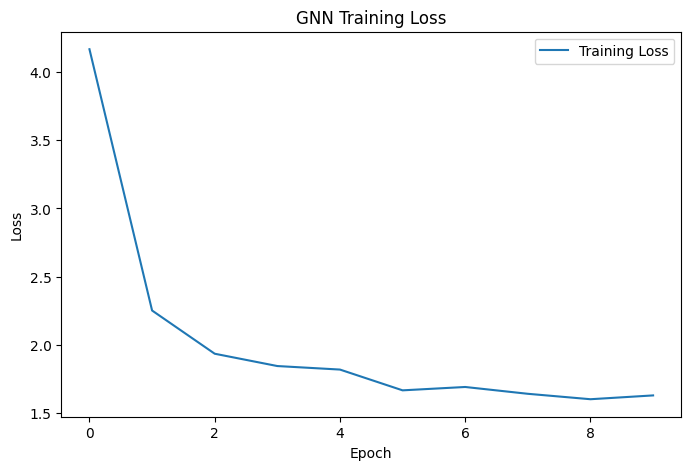

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    gnn_history["train_loss"],
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GNN Training Loss")
plt.legend()

plt.show()

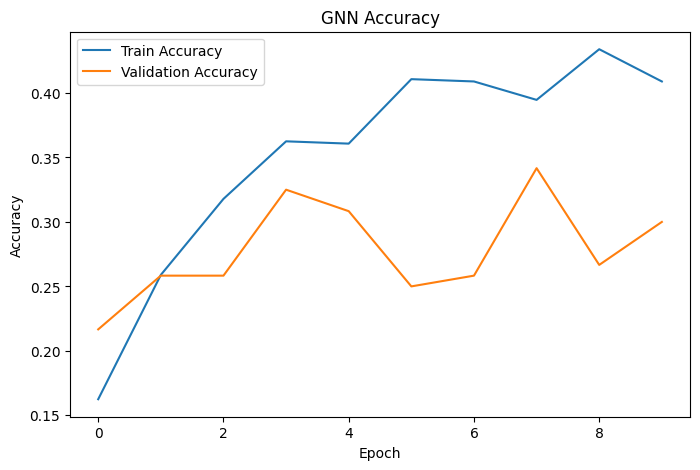

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    gnn_history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    gnn_history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GNN Accuracy")
plt.legend()

plt.show()

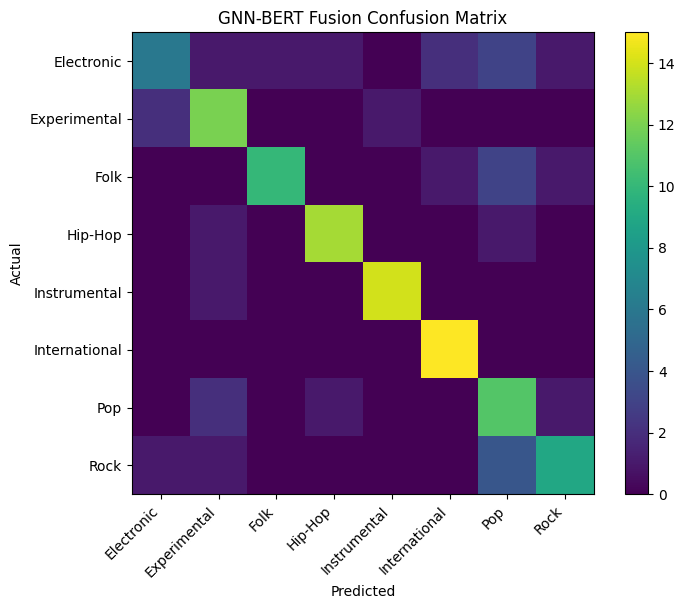

In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    fusion_true,
    fusion_pred
)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xticks(
    range(len(genres)),
    genres,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(genres)),
    genres
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    "GNN-BERT Fusion Confusion Matrix"
)

plt.colorbar()

plt.show()

# Example predictions

In [56]:
fusion_model.eval()

examples = []

with torch.no_grad():

    for batch in test_fusion_loader:

        graph = batch[
            "graph"
        ].to(device)

        input_ids = batch[
            "input_ids"
        ].to(device)

        attention_mask = batch[
            "attention_mask"
        ].to(device)

        logits, _ = fusion_model(
            graph,
            input_ids,
            attention_mask
        )

        predictions = logits.argmax(
            dim=1
        )

        for i in range(
            len(predictions)
        ):

            examples.append({
                "True": genres[
                    batch[
                        "label"
                    ][i].item()
                ],

                "Predicted": genres[
                    predictions[
                        i
                    ].item()
                ]
            })

        if len(examples) >= 5:
            break

pd.DataFrame(
    examples[:5]
)

,True,Predicted
0,Instrumental,Instrumental
1,Folk,International
2,Folk,Folk
3,Electronic,Pop
4,Folk,Folk


# t-SNE

In [57]:
from sklearn.manifold import TSNE

fusion_model.eval()

embeddings = []
labels = []

with torch.no_grad():

    for batch in test_fusion_loader:

        graph = batch[
            "graph"
        ].to(device)

        input_ids = batch[
            "input_ids"
        ].to(device)

        attention_mask = batch[
            "attention_mask"
        ].to(device)

        _, embedding = fusion_model(
            graph,
            input_ids,
            attention_mask
        )

        embeddings.append(
            embedding.cpu().numpy()
        )

        labels.extend(
            batch["label"].numpy()
        )

embeddings = np.vstack(
    embeddings
)

labels = np.array(
    labels
)

print(
    "Embedding shape:",
    embeddings.shape
)

Embedding shape: (120, 832)


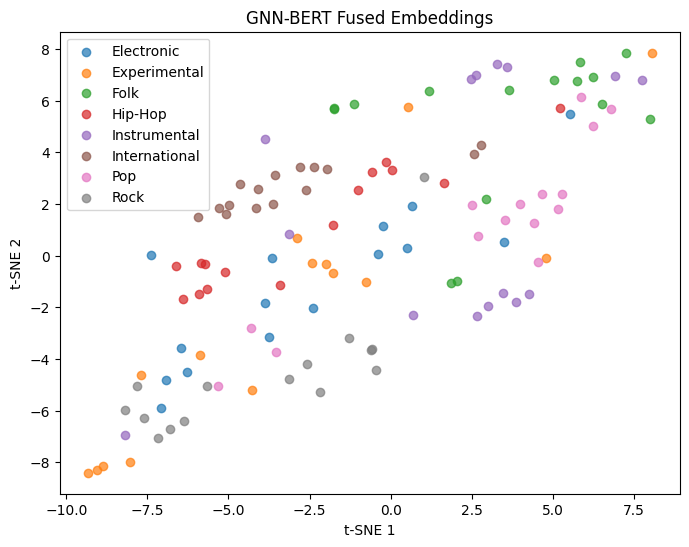

In [58]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

embedding_2d = tsne.fit_transform(
    embeddings
)

plt.figure(figsize=(8, 6))

for class_id, genre in enumerate(
    genres
):

    mask = labels == class_id

    plt.scatter(
        embedding_2d[mask, 0],
        embedding_2d[mask, 1],
        label=genre,
        alpha=0.7
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title(
    "GNN-BERT Fused Embeddings"
)

plt.legend()

plt.show()

# Graph Case Studies

In [59]:
case_ids = test_ids[:3]

for track_id in case_ids:

    graph = torch.load(
        os.path.join(
            graph_dir,
            f"{int(track_id):06d}.pt"
        ),
        weights_only=False
    )

    print("=" * 60)

    print(
        "Track:",
        track_id
    )

    print(
        "Metadata:",
        get_text(track_id)
    )

    print(
        "True genre:",
        tracks.loc[
            track_id,
            ("track", "genre_top")
        ]
    )

    print(
        "Nodes:",
        graph.num_nodes
    )

    print(
        "Edges:",
        graph.num_edges
    )

    print(
        "Edge index:"
    )

    print(
        graph.edge_index
    )

Track: 45393
Metadata: Artist: Blear Moon. Album: Sauvignon Valley. Track: Le dernier.
True genre: Instrumental
Nodes: 6
Edges: 30
Edge index:
tensor([[4, 3, 4, 3, 5, 5, 0, 0, 1, 2, 1, 4, 3, 4, 5, 5, 0, 2, 1, 0, 2, 1, 3, 4,
         3, 5, 0, 2, 1, 2],
        [0, 4, 3, 1, 4, 1, 2, 5, 0, 5, 3, 2, 0, 5, 0, 3, 1, 4, 2, 4, 1, 5, 2, 1,
         5, 2, 3, 0, 4, 3]])
Track: 1544
Metadata: Artist: Samara Lubelski. Album: In The Valley. Track: Song of The Stations.
True genre: Folk
Nodes: 6
Edges: 30
Edge index:
tensor([[4, 3, 4, 3, 5, 5, 0, 0, 1, 2, 1, 4, 3, 4, 5, 5, 0, 2, 1, 0, 2, 1, 3, 4,
         3, 5, 0, 2, 1, 2],
        [0, 4, 3, 1, 4, 1, 2, 5, 0, 5, 3, 2, 0, 5, 0, 3, 1, 4, 2, 4, 1, 5, 2, 1,
         5, 2, 3, 0, 4, 3]])
Track: 210
Metadata: Artist: Ed Askew. Album: Blue Piano. Track: In the French Court.
True genre: Folk
Nodes: 6
Edges: 30
Edge index:
tensor([[4, 3, 4, 3, 5, 5, 0, 0, 1, 2, 1, 4, 3, 4, 5, 5, 0, 2, 1, 0, 2, 1, 3, 4,
         3, 5, 0, 2, 1, 2],
        [0, 4, 3, 1, 4, 1, 2, 

# Saving

In [60]:
os.makedirs(
    "/content/fma/results/plots",
    exist_ok=True
)

os.makedirs(
    "/content/fma/results/retrieval_examples",
    exist_ok=True
)

In [61]:
import json

metrics = {

    "cnn_accuracy": float(
        accuracy_score(
            cnn_true,
            cnn_pred
        )
    ),

    "cnn_macro_f1": float(
        f1_score(
            cnn_true,
            cnn_pred,
            average="macro"
        )
    ),

    "cnn_micro_f1": float(
        f1_score(
            cnn_true,
            cnn_pred,
            average="micro"
        )
    ),

    "gnn_accuracy": float(
        accuracy_score(
            gnn_true,
            gnn_pred
        )
    ),

    "gnn_macro_f1": float(
        f1_score(
            gnn_true,
            gnn_pred,
            average="macro"
        )
    ),

    "gnn_micro_f1": float(
        f1_score(
            gnn_true,
            gnn_pred,
            average="micro"
        )
    ),

    "bert_accuracy": float(
        accuracy_score(
            bert_true,
            bert_pred
        )
    ),

    "bert_macro_f1": float(
        f1_score(
            bert_true,
            bert_pred,
            average="macro"
        )
    ),

    "bert_micro_f1": float(
        f1_score(
            bert_true,
            bert_pred,
            average="micro"
        )
    ),

    "fusion_accuracy": float(
        accuracy_score(
            fusion_true,
            fusion_pred
        )
    ),

    "fusion_macro_f1": float(
        f1_score(
            fusion_true,
            fusion_pred,
            average="macro"
        )
    ),

    "fusion_micro_f1": float(
        f1_score(
            fusion_true,
            fusion_pred,
            average="micro"
        )
    )
}

with open(
    "/content/fma/results/metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=2
    )

print("Metrics saved.")

Metrics saved.


In [62]:
torch.save(
    gnn_model.state_dict(),
    "/content/fma/results/gnn_model.pt"
)

torch.save(
    bert_model.state_dict(),
    "/content/fma/results/bert_model.pt"
)

torch.save(
    fusion_model.state_dict(),
    "/content/fma/results/fusion_model.pt"
)

torch.save(
    cnn_model.state_dict(),
    "/content/fma/results/cnn_model.pt"
)

print("Models saved.")

Models saved.


# Constrastive (Task 4)

In [63]:
class ContrastiveDataset(Dataset):

    def __init__(self, track_ids):
        self.track_ids = track_ids

    def __len__(self):
        return len(self.track_ids)

    def __getitem__(self, idx):

        track_id = self.track_ids[idx]

        graph = torch.load(
            os.path.join(
                graph_dir,
                f"{int(track_id):06d}.pt"
            ),
            weights_only=False
        )

        text = get_text(track_id)

        encoded = tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=CONFIG["max_text_length"],
            return_tensors="pt"
        )

        return {
            "graph": graph,
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "track_id": track_id
        }


train_contrastive_dataset = ContrastiveDataset(train_ids)
val_contrastive_dataset = ContrastiveDataset(val_ids)
test_contrastive_dataset = ContrastiveDataset(test_ids)

print(
    "Train:",
    len(train_contrastive_dataset)
)

print(
    "Validation:",
    len(val_contrastive_dataset)
)

print(
    "Test:",
    len(test_contrastive_dataset)
)

Train: 560
Validation: 120
Test: 120


In [64]:
def contrastive_collate(batch):

    graphs = [
        item["graph"]
        for item in batch
    ]

    graph_batch = Batch.from_data_list(
        graphs
    )

    input_ids = torch.stack([
        item["input_ids"]
        for item in batch
    ])

    attention_mask = torch.stack([
        item["attention_mask"]
        for item in batch
    ])

    track_ids = [
        item["track_id"]
        for item in batch
    ]

    return {
        "graph": graph_batch,
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "track_ids": track_ids
    }


train_contrastive_loader = DataLoader(
    train_contrastive_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=contrastive_collate
)

val_contrastive_loader = DataLoader(
    val_contrastive_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=contrastive_collate
)

test_contrastive_loader = DataLoader(
    test_contrastive_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=contrastive_collate
)

print("Contrastive DataLoaders ready.")

Contrastive DataLoaders ready.


In [65]:
class ContrastiveModel(nn.Module):

    def __init__(
        self,
        gnn_model,
        bert_model,
        projection_dim=128
    ):

        super().__init__()

        self.gnn = gnn_model
        self.bert = bert_model

        self.audio_projection = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, projection_dim)
        )

        self.text_projection = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Linear(256, projection_dim)
        )

        self.logit_scale = nn.Parameter(
            torch.tensor(np.log(1 / 0.07))
        )

    def forward(
        self,
        graph_batch,
        input_ids,
        attention_mask
    ):

        # Audio / graph embedding
        _, audio_embedding = self.gnn(
            graph_batch.x,
            graph_batch.edge_index,
            graph_batch.batch
        )

        # Text embedding
        _, text_embedding = self.bert(
            input_ids,
            attention_mask,
            return_embedding=True
        )

        audio_embedding = self.audio_projection(
            audio_embedding
        )

        text_embedding = self.text_projection(
            text_embedding
        )

        # Normalize embeddings
        audio_embedding = F.normalize(
            audio_embedding,
            dim=1
        )

        text_embedding = F.normalize(
            text_embedding,
            dim=1
        )

        scale = self.logit_scale.exp()

        logits = scale * (
            audio_embedding @
            text_embedding.T
        )

        return (
            audio_embedding,
            text_embedding,
            logits
        )


contrastive_model = ContrastiveModel(
    gnn_model,
    bert_model
).to(device)

print(contrastive_model)

ContrastiveModel(
  (gnn): GraphSAGEModel(
    (conv1): SAGEConv(25, 64, aggr=mean)
    (conv2): SAGEConv(64, 64, aggr=mean)
    (classifier): Linear(in_features=64, out_features=8, bias=True)
  )
  (bert): BERTClassifier(
    (bert): DistilBertModel(
      (embeddings): Embeddings(
        (word_embeddings): Embedding(30522, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (transformer): Transformer(
        (layer): ModuleList(
          (0-5): 6 x TransformerBlock(
            (attention): DistilBertSelfAttention(
              (q_lin): Linear(in_features=768, out_features=768, bias=True)
              (k_lin): Linear(in_features=768, out_features=768, bias=True)
              (v_lin): Linear(in_features=768, out_features=768, bias=True)
              (out_lin): Linear(in_features=768, out_features=768, bias=True)
           

In [66]:
def contrastive_loss(logits):

    batch_size = logits.size(0)

    labels = torch.arange(
        batch_size,
        device=logits.device
    )

    audio_to_text_loss = F.cross_entropy(
        logits,
        labels
    )

    text_to_audio_loss = F.cross_entropy(
        logits.T,
        labels
    )

    return (
        audio_to_text_loss +
        text_to_audio_loss
    ) / 2

In [67]:
contrastive_optimizer = torch.optim.AdamW(
    contrastive_model.parameters(),
    lr=1e-4
)

contrastive_history = []

for epoch in range(5):

    contrastive_model.train()

    total_loss = 0

    for batch in train_contrastive_loader:

        graph = batch["graph"].to(device)

        input_ids = batch[
            "input_ids"
        ].to(device)

        attention_mask = batch[
            "attention_mask"
        ].to(device)

        contrastive_optimizer.zero_grad()

        _, _, logits = contrastive_model(
            graph,
            input_ids,
            attention_mask
        )

        loss = contrastive_loss(
            logits
        )

        loss.backward()

        contrastive_optimizer.step()

        total_loss += loss.item()

    average_loss = (
        total_loss /
        len(train_contrastive_loader)
    )

    contrastive_history.append(
        average_loss
    )

    print(
        f"Epoch {epoch + 1}/5 | "
        f"Loss: {average_loss:.4f}"
    )

Epoch 1/5 | Loss: 1.9859
Epoch 2/5 | Loss: 1.6721
Epoch 3/5 | Loss: 1.3794
Epoch 4/5 | Loss: 1.2607
Epoch 5/5 | Loss: 1.1306


In [68]:
def get_contrastive_embeddings(
    model,
    loader
):

    model.eval()

    all_audio = []
    all_text = []
    all_ids = []

    with torch.no_grad():

        for batch in loader:

            graph = batch[
                "graph"
            ].to(device)

            input_ids = batch[
                "input_ids"
            ].to(device)

            attention_mask = batch[
                "attention_mask"
            ].to(device)

            audio_embedding, text_embedding, _ = (
                model(
                    graph,
                    input_ids,
                    attention_mask
                )
            )

            all_audio.append(
                audio_embedding.cpu()
            )

            all_text.append(
                text_embedding.cpu()
            )

            all_ids.extend(
                batch["track_ids"]
            )

    return (
        torch.cat(all_audio),
        torch.cat(all_text),
        all_ids
    )


test_audio_embeddings, test_text_embeddings, test_track_ids = (
    get_contrastive_embeddings(
        contrastive_model,
        test_contrastive_loader
    )
)

print(
    "Audio embeddings:",
    test_audio_embeddings.shape
)

print(
    "Text embeddings:",
    test_text_embeddings.shape
)

Audio embeddings: torch.Size([120, 128])
Text embeddings: torch.Size([120, 128])


# Audio to Text Retrieval

In [69]:
similarity_matrix = (
    test_audio_embeddings @
    test_text_embeddings.T
)

print(
    "Similarity matrix:",
    similarity_matrix.shape
)

Similarity matrix: torch.Size([120, 120])


In [70]:
def recall_at_k(
    similarity_matrix,
    k
):

    correct = 0

    for i in range(
        similarity_matrix.size(0)
    ):

        top_k = torch.topk(
            similarity_matrix[i],
            k=k
        ).indices

        if i in top_k:
            correct += 1

    return correct / similarity_matrix.size(0)


for k in [1, 5, 10]:

    print(
        f"Audio -> Text Recall@{k}:",
        recall_at_k(
            similarity_matrix,
            k
        )
    )

Audio -> Text Recall@1: 0.05
Audio -> Text Recall@5: 0.21666666666666667
Audio -> Text Recall@10: 0.325


# Text to Audio Retrieval

In [71]:
reverse_similarity = (
    test_text_embeddings @
    test_audio_embeddings.T
)

for k in [1, 5, 10]:

    print(
        f"Text -> Audio Recall@{k}:",
        recall_at_k(
            reverse_similarity,
            k
        )
    )

Text -> Audio Recall@1: 0.041666666666666664
Text -> Audio Recall@5: 0.175
Text -> Audio Recall@10: 0.35


# Examples

In [72]:
print("=" * 70)
print("CONTRASTIVE RETRIEVAL EXAMPLES")
print("=" * 70)

for i in range(min(5, len(test_track_ids))):

    ranked = torch.argsort(
        similarity_matrix[i],
        descending=True
    )

    print()
    print(
        "Query track:",
        test_track_ids[i]
    )

    print(
        "Query text:",
        get_text(
            test_track_ids[i]
        )
    )

    print("Top retrieved tracks:")

    for rank in range(3):

        retrieved_index = ranked[
            rank
        ].item()

        retrieved_id = test_track_ids[
            retrieved_index
        ]

        print(
            f"  {rank + 1}. "
            f"{retrieved_id} | "
            f"{get_text(retrieved_id)}"
        )

CONTRASTIVE RETRIEVAL EXAMPLES

Query track: 45393
Query text: Artist: Blear Moon. Album: Sauvignon Valley. Track: Le dernier.
Top retrieved tracks:
  1. 5376 | Artist: Mary Halvorson and Jessica Pavone. Album: Live at WFMU on Bethany's Show on 9/10/2006. Track: The Clouds.
  2. 210 | Artist: Ed Askew. Album: Blue Piano. Track: In the French Court.
  3. 625 | Artist: Ed Askew. Album: Rainy Day Song. Track: Climbing To The Top.

Query track: 1544
Query text: Artist: Samara Lubelski. Album: In The Valley. Track: Song of The Stations.
Top retrieved tracks:
  1. 20375 | Artist: Ergo Phizmiz. Album: Outtakes from "The Snow Flea". Track: Northern Lights.
  2. 14570 | Artist: Ergo Phizmiz. Album: Music from "The House of Dr Faustus". Track: So Wunsch Ich Dir.
  3. 14576 | Artist: Ergo Phizmiz. Album: Music from "The House of Dr Faustus". Track: Funeral March For A Marionette.

Query track: 210
Query text: Artist: Ed Askew. Album: Blue Piano. Track: In the French Court.
Top retrieved tracks:
 

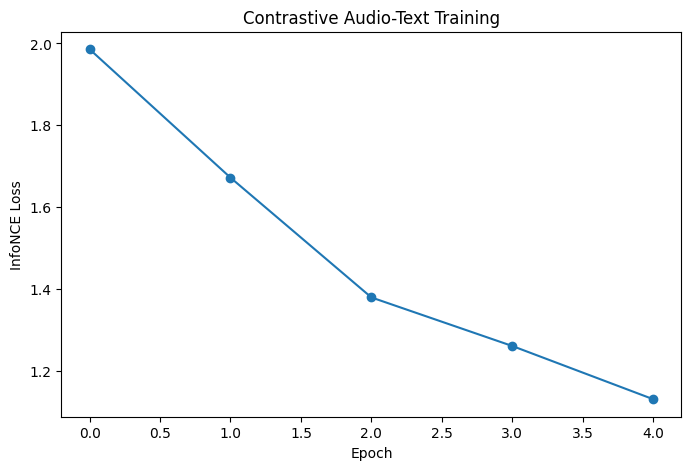

In [73]:
plt.figure(figsize=(8, 5))

plt.plot(
    contrastive_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("InfoNCE Loss")
plt.title(
    "Contrastive Audio-Text Training"
)

plt.show()

# Saving

In [74]:
contrastive_metrics = {}

for k in [1, 5, 10]:

    contrastive_metrics[
        f"audio_to_text_recall_at_{k}"
    ] = recall_at_k(
        similarity_matrix,
        k
    )

    contrastive_metrics[
        f"text_to_audio_recall_at_{k}"
    ] = recall_at_k(
        reverse_similarity,
        k
    )

with open(
    "/content/fma/results/contrastive_metrics.json",
    "w"
) as f:

    json.dump(
        contrastive_metrics,
        f,
        indent=2
    )

torch.save(
    contrastive_model.state_dict(),
    "/content/fma/results/contrastive_model.pt"
)

print(
    "Task 4 results and model saved."
)

print(
    contrastive_metrics
)

Task 4 results and model saved.
{'audio_to_text_recall_at_1': 0.05, 'text_to_audio_recall_at_1': 0.041666666666666664, 'audio_to_text_recall_at_5': 0.21666666666666667, 'text_to_audio_recall_at_5': 0.175, 'audio_to_text_recall_at_10': 0.325, 'text_to_audio_recall_at_10': 0.35}


In [75]:
print(results)

              Model  Accuracy  Macro-F1  Micro-F1
0  CNN Mel Baseline  0.183333  0.085518  0.183333
1     GNN GraphSAGE  0.366667  0.333018  0.366667
2         BERT-only  0.783333  0.780632  0.783333
3   GNN-BERT Fusion  0.750000  0.745857  0.750000


In [76]:
print(
    json.dumps(
        contrastive_metrics,
        indent=2
    )
)

{
  "audio_to_text_recall_at_1": 0.05,
  "text_to_audio_recall_at_1": 0.041666666666666664,
  "audio_to_text_recall_at_5": 0.21666666666666667,
  "text_to_audio_recall_at_5": 0.175,
  "audio_to_text_recall_at_10": 0.325,
  "text_to_audio_recall_at_10": 0.35
}


# Combined Final Metrics

In [77]:
all_metrics = {
    "classification": metrics,
    "contrastive_retrieval": contrastive_metrics
}

with open(
    "/content/fma/results/all_metrics.json",
    "w"
) as f:
    json.dump(
        all_metrics,
        f,
        indent=2
    )

print("All final metrics saved.")

All final metrics saved.


# Project Summary

In [78]:
summary = {
    "dataset": "FMA-small",
    "tracks": 800,
    "genres": genres,
    "segments_per_track": 6,
    "node_features": 25,
    "gnn": "GraphSAGE",
    "text_encoder": "DistilBERT",
    "fusion": "GNN + DistilBERT",
    "contrastive_learning": "InfoNCE",
    "task_4_dataset_note": (
        "Simplified MusicCaps-style audio-text "
        "contrastive learning using FMA metadata text."
    )
}

with open(
    "/content/fma/results/project_summary.json",
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )

print(
    json.dumps(
        summary,
        indent=2
    )
)

{
  "dataset": "FMA-small",
  "tracks": 800,
  "genres": [
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Pop",
    "Rock"
  ],
  "segments_per_track": 6,
  "node_features": 25,
  "gnn": "GraphSAGE",
  "text_encoder": "DistilBERT",
  "fusion": "GNN + DistilBERT",
  "contrastive_learning": "InfoNCE",
  "task_4_dataset_note": "Simplified MusicCaps-style audio-text contrastive learning using FMA metadata text."
}


In [79]:
import os

print("=== RESULTS ===")

for root, dirs, files in os.walk(
    "/content/fma/results"
):

    for file in files:

        path = os.path.join(
            root,
            file
        )

        print(path)

=== RESULTS ===
/content/fma/results/contrastive_model.pt
/content/fma/results/cnn_model.pt
/content/fma/results/gnn_model.pt
/content/fma/results/bert_model.pt
/content/fma/results/metrics.json
/content/fma/results/fusion_model.pt
/content/fma/results/all_metrics.json
/content/fma/results/project_summary.json
/content/fma/results/contrastive_metrics.json


In [80]:
!zip -r /content/GNN-BERT-results.zip /content/fma/results

  adding: content/fma/results/ (stored 0%)
  adding: content/fma/results/contrastive_model.pt (deflated 8%)
  adding: content/fma/results/cnn_model.pt (deflated 9%)
  adding: content/fma/results/plots/ (stored 0%)
  adding: content/fma/results/retrieval_examples/ (stored 0%)
  adding: content/fma/results/gnn_model.pt (deflated 11%)
  adding: content/fma/results/bert_model.pt (deflated 8%)
  adding: content/fma/results/metrics.json (deflated 66%)
  adding: content/fma/results/fusion_model.pt (deflated 8%)
  adding: content/fma/results/all_metrics.json (deflated 68%)
  adding: content/fma/results/project_summary.json (deflated 41%)
  adding: content/fma/results/contrastive_metrics.json (deflated 66%)


In [81]:
from google.colab import files

files.download(
    "/content/GNN-BERT-results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>